In [2]:
#7.Load the breast cancer dataset from scikit learn, which gives you around thirty numeric columns to work with.
#8.Split into training and testing sets first, then fit a StandardScaler on the training portion only, exactly as you learned on Day 12.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#9.Fit PCA on the scaled training data and print the explained variance ratio of the first several components.
from sklearn.decomposition import PCA
pca=PCA()
pca.fit(x_train_scaled)
print(pca.explained_variance_ratio_)


[4.35027816e-01 1.95000069e-01 9.78151887e-02 6.48640944e-02
 5.25337760e-02 4.11279962e-02 2.23559034e-02 1.64795219e-02
 1.38005190e-02 1.20526216e-02 1.05656532e-02 8.83487978e-03
 7.72384348e-03 5.31689053e-03 2.90035907e-03 2.74863963e-03
 2.02120554e-03 1.81312048e-03 1.63703163e-03 1.03921453e-03
 9.98523858e-04 8.78835623e-04 8.09819261e-04 5.76666950e-04
 4.96295906e-04 2.76290404e-04 2.25813282e-04 5.07660981e-05
 2.45885848e-05 4.05623540e-06]


[0.43502782 0.63002788 0.72784307 0.79270717 0.84524094 0.88636894
 0.90872484 0.92520437 0.93900488 0.95105751 0.96162316 0.97045804
 0.97818188 0.98349877 0.98639913 0.98914777 0.99116898 0.9929821
 0.99461913 0.99565834 0.99665687 0.9975357  0.99834552 0.99892219
 0.99941849 0.99969478 0.99992059 0.99997136 0.99999594 1.        ]


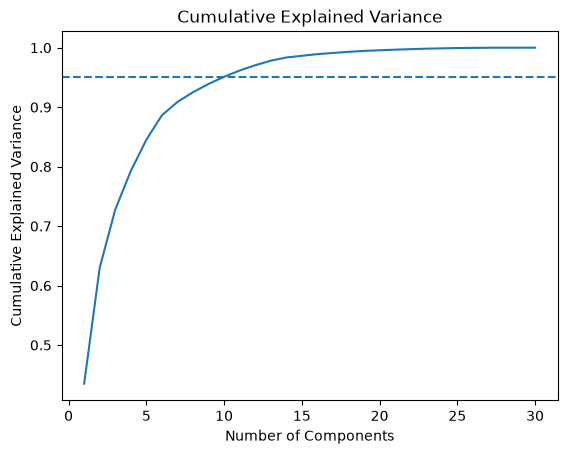

Components needed for 95% information: 10


In [6]:
#10.Plot the cumulative explained variance and decide how many components you need in order to keep roughly ninety five percent of the information.
import matplotlib.pyplot as plt
import numpy as np
commulative_variance=np.cumsum(pca.explained_variance_ratio_)
print(commulative_variance)
plt.plot(range(1,len(commulative_variance)+1),commulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.axhline(y=0.95,linestyle="--")
plt.show()
n_components = np.argmax(commulative_variance >= 0.95) + 1
print("Components needed for 95% information:", n_components)

(455, 2)


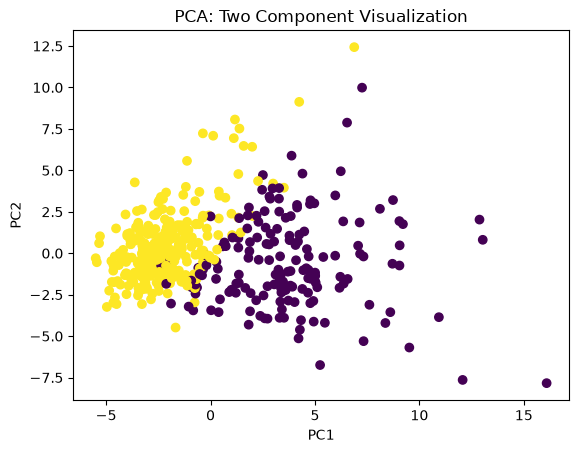

In [7]:
from sklearn.decomposition import PCA
pca_2=PCA(n_components=2)
pca_2.fit(x_train_scaled)
x_train_pca=pca_2.transform(x_train_scaled)
print(x_train_pca.shape)
plt.scatter(x_train_pca[:, 0],x_train_pca[:, 1],c=y_train)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Two Component Visualization")
plt.show()

In [19]:
from sklearn.linear_model import LogisticRegression
import time
model_original = LogisticRegression(max_iter=1000)
start = time.time()
model_original.fit(x_train_scaled, y_train)
original_time = time.time() - start
accuracy_original = model_original.score(X_test_scaled, y_test)
model_pca = LogisticRegression(max_iter=1000)
start = time.time()
model_pca.fit(x_train_pca, y_train)
pca_time = time.time() - start
X_test_pca = pca_2.transform(X_test_scaled)
accuracy_pca = model_pca.score(X_test_pca, y_test)
# Comparison
print("Original Accuracy:", accuracy_original)
print("PCA Accuracy:", accuracy_pca)
print("Original Training Time:", original_time)
print("PCA Training Time:", pca_time)

Original Accuracy: 0.9736842105263158
PCA Accuracy: 0.9912280701754386
Original Training Time: 0.021303176879882812
PCA Training Time: 0.011088132858276367
